# Máquinas Térmicas - Lección 3
## Ciclos Biogeoquímicos y Geología de los Hidrocarburos  

**Autor:** Camilo Bayona  
**Fecha:** 23/07/2025




### Objetivos de aprendizaje  

1. Describir los procesos y reservorios principales de los ciclos del **agua, carbono y nitrógeno**, entre otros.  
2. Relacionar dichos ciclos con la formación, acumulación y extracción de **combustibles fósiles**.  
3. Aplicar balances de masa sencillos para cuantificar flujos y tiempos de residencia.  
4. Introducir los conceptos básicos de **geología del petróleo** (roca generadora, migración, trampas).  
5. Preparar el terreno para la lección siguiente sobre **combustibles convencionales y su combustión**.


## 1. Introducción

Los ciclos biogeoquímicos describen la circulación de la materia a través de la **biosfera, atmósfera, hidrósfera y litosfera**.  
Estos ciclos regulan la disponibilidad de nutrientes para los seres vivos y determinan cómo se transfiere la energía entre organismos y su entorno.

Para los ingenieros mecánicos, entender estos ciclos es esencial porque explican el origen de los **combustibles fósiles** (carbón, petróleo y gas natural), que se formaron a partir de materia orgánica sometida a procesos geológicos de largo plazo:
* **Suministro de energía:** los hidrocarburos que usamos como combustible son el resultado de millones de años de evolución dentro del ciclo del carbono y del agua.  
* **Impacto ambiental:** las emisiones de CO₂, H₂O y NOₓ generadas en procesos térmicos vuelven a dichos ciclos y alteran su equilibrio.

,Esfera,Descripción (muy breve),Masa aprox.,Función en ciclos BGQ
0,Litosfera,Corteza + parte superior del manto (~0-100 km),≈ 4 × 10²⁴ kg,"Fuente y sumidero de C, N, S a muy largo plazo"
1,Hidrósfera,"Aguas oceánicas, continentales y subterráneas",≈ 1.4 × 10²¹ kg,"Intercambio rápido H₂O, C y calor (clima)"
2,Biosfera,Conjunto de seres vivos y materia orgánica activa,≈ 1 × 10¹⁵ kg,"Fija C y N, libera O₂, regula flujos energéticos"
3,Atmósfera,"Capa gaseosa (troposfera-estratosfera, etc.)",≈ 5 × 10¹⁸ kg,Almacén y transporte de gases reactivos y vapor


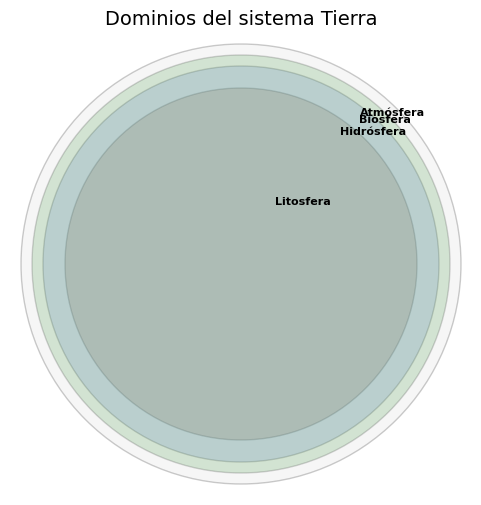

In [ ]:
# Esferas del sistema Tierra: diagrama y datos básicos
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------
# 1. Datos resumidos
# ---------------------------
datos = pd.DataFrame({
    "Esfera":      ["Litosfera", "Hidrósfera", "Biosfera", "Atmósfera"],
    "Descripción (muy breve)": [
        "Corteza + parte superior del manto (~0-100 km)",
        "Aguas oceánicas, continentales y subterráneas",
        "Conjunto de seres vivos y materia orgánica activa",
        "Capa gaseosa (troposfera-estratosfera, etc.)"
    ],
    "Masa aprox.": ["≈ 4 × 10²⁴ kg", "≈ 1.4 × 10²¹ kg", "≈ 1 × 10¹⁵ kg", "≈ 5 × 10¹⁸ kg"],
    "Función en ciclos BGQ": [
        "Fuente y sumidero de C, N, S a muy largo plazo",
        "Intercambio rápido H₂O, C y calor (clima)",
        "Fija C y N, libera O₂, regula flujos energéticos",
        "Almacén y transporte de gases reactivos y vapor"
    ]
})

# Mostrar tabla (en Jupyter aparece como HTML interactivo)
display(datos)

# ---------------------------
# 2. Diagrama concéntrico
# ---------------------------
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')

# Definición de capas: (nombre, radio exterior, color)
capas = [
    ("Litosfera", 0.80, "saddlebrown"),
    ("Hidrósfera", 0.90, "royalblue"),
    ("Biosfera", 0.95, "forestgreen"),
    ("Atmósfera", 1.00, "lightgray")
]

radio_prev = 0.0
for nombre, radio_ext, color in capas:
    # Dibujar anillo
    ring = plt.Circle((0, 0), radio_ext, color=color, alpha=0.2,
                      ec='k', lw=1.0)
    ax.add_patch(ring)
    # Etiqueta ligeramente dentro del anillo
    angle = 45                           # grados
    r_text = (radio_prev + radio_ext) / 2
    x, y = r_text * np.cos(np.deg2rad(angle)), r_text * np.sin(np.deg2rad(angle))
    ax.text(x, y, nombre, ha='center', va='center', fontsize=8, weight='bold')
    radio_prev = radio_ext

ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.axis('off')
plt.title("Dominios del sistema Tierra", fontsize=14)
plt.show()

Este cuaderno explora los principales ciclos biogeoquímicos (agua, carbono, nitrógeno, azufre y fósforo) y explica cómo la dinámica de la materia en la Tierra está relacionada con la formación geológica del carbón y los hidrocarburos (petróleo y gas natural).

## Ciclo del agua (ciclo hidrológico)


El agua circula continuamente entre la atmósfera, la superficie y el subsuelo mediante procesos de **evaporación**, **condensación**, **precipitación** e **infiltración**. La precipitación que cae sobre la superficie se divide entre el flujo superficial (que alimenta ríos, lagos y humedales) y la infiltración en el suelo. Parte del agua infiltrada recarga los **acuíferos** y se mueve lentamente hacia cuerpos de agua superficiales; otra parte vuelve a la atmósfera por **evaporación**. Este ciclo regula la disponibilidad de agua dulce y controla procesos de erosión, transporte de sedimentos y formación de rocas sedimentarias.

La energía necesaria para evaporar el agua es grande; por ejemplo, evaporar 1 kilogramo de agua requiere aproximadamente 2,26 × 10⁶ J (calor de vaporización). Esta energía latente es importante en fenómenos meteorológicos y en el diseño de intercambiadores de calor.

![Representación abstracta del ciclo del agua](attachment:80df9948-8104-45a4-9c69-ce04249ee84a.png)

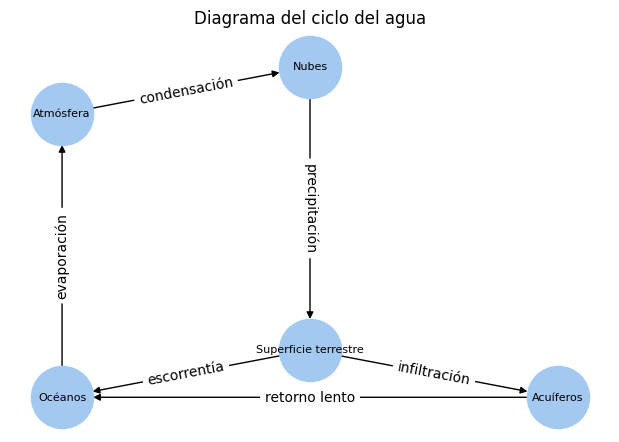

In [ ]:
# Diagrama simplificado del ciclo del agua
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()
nodos = ['Océanos', 'Atmósfera', 'Nubes', 'Superficie terrestre', 'Acuíferos']
G.add_nodes_from(nodos)
G.add_edge('Océanos', 'Atmósfera', label='evaporación')
G.add_edge('Atmósfera', 'Nubes', label='condensación')
G.add_edge('Nubes', 'Superficie terrestre', label='precipitación')
G.add_edge('Superficie terrestre', 'Océanos', label='escorrentía')
G.add_edge('Superficie terrestre', 'Acuíferos', label='infiltración')
G.add_edge('Acuíferos', 'Océanos', label='retorno lento')
pos = {
    'Océanos':(0,-1),
    'Atmósfera':(0,2),
    'Nubes':(1,2.5),
    'Superficie terrestre':(1,-0.5),
    'Acuíferos':(2,-1)
}
plt.figure(figsize=(6,4))
nx.draw(G, pos, with_labels=True, node_color='#a3c9f1', node_size=2000, font_size=8, arrows=True)
edge_labels = nx.get_edge_attributes(G,'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)
plt.title('Diagrama del ciclo del agua')
plt.axis('off')
plt.show()


* **Reservorios:** océanos (~97 %), hielo continental, aguas subterráneas, atmósfera, biosfera.  
* **Flujos clave:** evaporación, condensación, precipitación, escorrentía, infiltración.  
* **Tiempo de residencia promedio:**  
  * Atmósfera ≈ 9 días  
  * Océanos ≈ 3 000 años

> _Notación_: \( F_{ij} \) = flujo del reservorio _i_ al _j_ [kg · a⁻¹];  
> \( M_i \) = masa en el reservorio _i_ [kg].

### 2.2 Código de ejemplo – Balance simplificado

In [ ]:
import pandas as pd

# -----------------------------
# 1. Definición de flujos (kg/a)
# -----------------------------
# Valores anuales aproximados del ciclo global (puedes cambiarlos)
F_EVA = 4.34e14   # evaporación océanos → atmósfera
F_PRE = 1.11e14   # precipitación nubes → superficie (continental)
F_INF = 0.30e14   # infiltración superficie → acuíferos
RET_FACTOR = 100  # retorno lento (p.e. 1/100 del flujo infiltrado)

# Se convierten a kg/s (divide entre segundos del año)
SEC_AÑO = 365 * 24 * 3600
kg_s = lambda kg_a: kg_a / SEC_AÑO

# Lista de arcos: (origen, destino, proceso, caudal kg/s)
flows = [
    ("Océanos", "Atmósfera", "evaporación",         kg_s(F_EVA)),
    ("Atmósfera", "Nubes",   "condensación",        kg_s(F_EVA)),  # mismo caudal por simplif.
    ("Nubes", "Superficie",  "precipitación",       kg_s(F_PRE)),
    ("Superficie", "Océanos","escorrentía",         kg_s(F_PRE)),
    ("Superficie", "Acuíferos", "infiltración",     kg_s(F_INF)),
    ("Acuíferos", "Océanos", "retorno lento",       kg_s(F_INF/RET_FACTOR))
]

df = pd.DataFrame(flows, columns=["source", "target", "proceso", "kg_s"])

# -----------------------------
# 2. Balance de masas por nodo
# -----------------------------
inflow  = df.groupby("target")["kg_s"].sum()
outflow = df.groupby("source")["kg_s"].sum()
mass_balance = (inflow - outflow).rename("Δkg_s").fillna(0)

# -----------------------------
# 3. Balance energético
# -----------------------------
L_v = 2.5e6               # J/kg
g   = 9.81                # m/s²
h_avg = 1000              # m (promedio precipitación-escorrentía)

def energia(row):
    if row.proceso == "evaporación":       # absorbe calor (energía requerida)
        return  row.kg_s * L_v             # positivo = entra al sistema agua
    elif row.proceso == "condensación":    # libera calor
        return -row.kg_s * L_v             # negativo = sale
    elif row.proceso in ["precipitación", "escorrentía"]:
        return  row.kg_s * g * h_avg       # potencial gravitatoria
    else:
        return 0.0                         # infiltración/retorno ≈ despreciable

df["W"] = df.apply(energia, axis=1)

energy_in  = df.groupby("target")["W"].sum()
energy_out = df.groupby("source")["W"].sum()
energy_balance = (energy_in - energy_out).rename("ΔW").fillna(0)

# -----------------------------
# 4. Resultados condensados
# -----------------------------
report = pd.concat([mass_balance, energy_balance], axis=1).fillna(0)
print("BALANCE DE MASA Y ENERGÍA POR NODO\n(unidades: kg/s y W)\n")
display(report.round(3))

print("\nComprobación de conservación global:")
print(f" Σ flujos de masa = {df['kg_s'].sum():.3e} kg/s   ",
      f"Σ balance = {report['Δkg_s'].sum():.3e} kg/s")
print(f" Σ flujos de energía = {df['W'].abs().sum():.3e} W ",
      f"Σ balance = {report['ΔW'].sum():.3e} W")

## Ciclo del carbono

El carbono es un elemento esencial para la vida y circula entre la atmósfera, la biosfera, la hidrósfera y la litosfera. Los **productores** toman dióxido de carbono (CO₂) del aire o bicarbonato disuelto para realizar la **fotosíntesis**, produciendo compuestos orgánicos como la glucosa. Los **consumidores** obtienen el carbono al alimentarse de plantas y otros animales. Durante la **respiración**, los organismos descomponen compuestos orgánicos y liberan CO₂ a la atmósfera. Los restos de organismos y desechos se descomponen por acción de hongos y bacterias, liberando CO₂. El carbono también se almacena en rocas carbonatadas y en los océanos, y es liberado por **erupciones volcánicas**. En las capas profundas de la corteza, la acumulación de restos orgánicos dio origen a los **combustibles fósiles** (petróleo, gas natural y carbón). El uso intensivo de estos combustibles devuelve rápidamente a la atmósfera el carbono que estuvo almacenado durante millones de años.

En el ciclo geológico del carbono, la meteorización de las rocas libera carbono a los océanos, donde precipita como carbonatos y finalmente se convierte en piedra caliza; la subducción y el vulcanismo vuelven a liberar el carbono a la atmósfera.

![Representación abstracta del ciclo del carbono](attachment:2285e403-c816-40b8-87b5-6438495f103a.png)

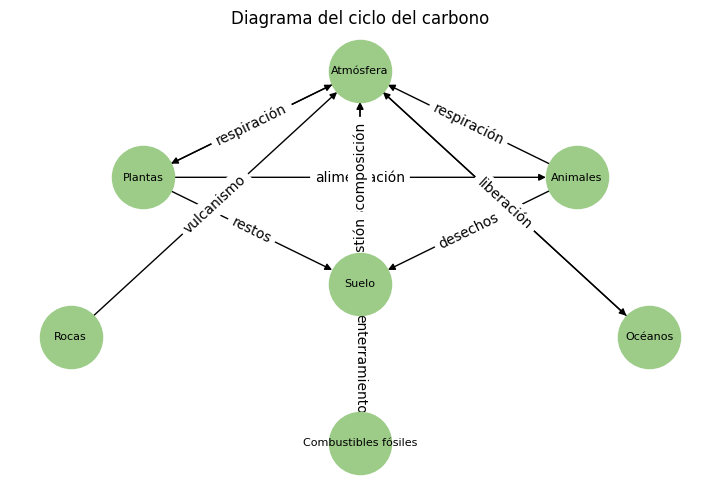

In [ ]:

# Diagrama simplificado del ciclo del carbono
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()
nodos = ['Atmósfera', 'Plantas', 'Animales', 'Suelo', 'Océanos', 'Rocas', 'Combustibles fósiles']
G.add_nodes_from(nodos)
G.add_edge('Atmósfera', 'Plantas', label='fotosíntesis')
G.add_edge('Plantas', 'Animales', label='alimentación')
G.add_edge('Animales', 'Atmósfera', label='respiración')
G.add_edge('Plantas', 'Atmósfera', label='respiración')
G.add_edge('Animales', 'Suelo', label='desechos')
G.add_edge('Plantas', 'Suelo', label='restos')
G.add_edge('Suelo', 'Atmósfera', label='descomposición')
G.add_edge('Atmósfera', 'Océanos', label='disolución')
G.add_edge('Océanos', 'Atmósfera', label='liberación')
G.add_edge('Suelo', 'Combustibles fósiles', label='enterramiento')
G.add_edge('Combustibles fósiles', 'Atmósfera', label='combustión')
G.add_edge('Rocas', 'Atmósfera', label='vulcanismo')
pos = {
    'Atmósfera':(0,2),
    'Plantas':(-1.5,1),
    'Animales':(1.5,1),
    'Suelo':(0,0),
    'Océanos':(2,-0.5),
    'Rocas':(-2,-0.5),
    'Combustibles fósiles':(0,-1.5)
}
plt.figure(figsize=(7,4.5))
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='#9dcc89', font_size=8, arrowsize=10)
edge_labels = nx.get_edge_attributes(G,'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)
plt.title('Diagrama del ciclo del carbono')
plt.axis('off')
plt.show()


| Reservorio          | Masa (Gt C) | Flujo principal (Gt C a⁻¹)                   |
| ------------------- | ----------- | -------------------------------------------- |
| Atmósfera           | 880         | Fotosíntesis (−120) / Combustión fósil (+11) |
| Biosfera            | 560         | Respiración (+119)                           |
| Océano superficial  | 900         | Intercambio aire-mar (±70)                   |
| Sedimentos/petróleo | 4 000 000   | Enterramiento (0.2)                          |


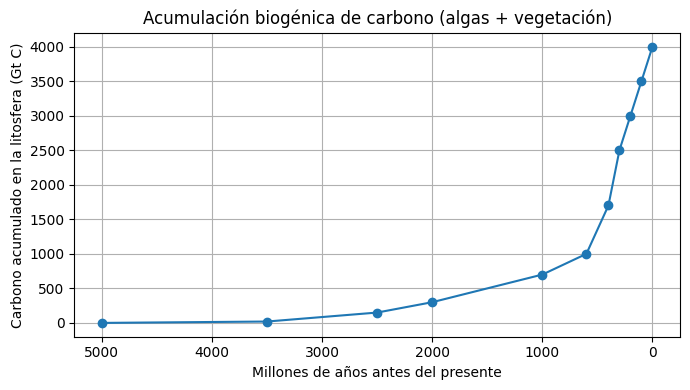

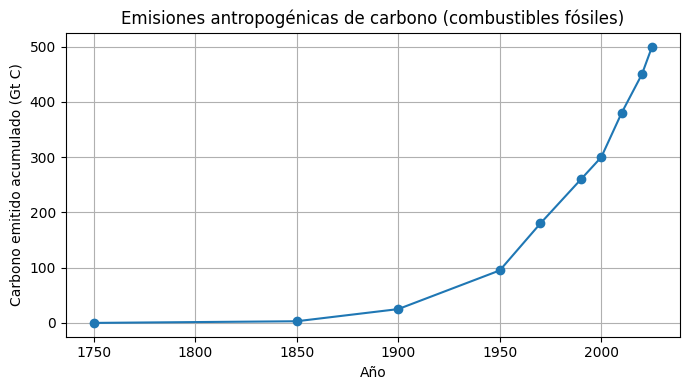

In [ ]:
# Acumulación vs. emisiones de carbono: escala geológica y escala industrial
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1) Acumulación de carbono biogénico (Gt C) – datos sintéticos
#    Puntos de referencia aproximados de la literatura
tiempo_ma = np.array([5000, 3500, 2500, 2000, 1000, 600, 400, 300, 200, 100,   0])
carbono_gtc = np.array([   0,   20,  150,  300,  700, 1000, 1700, 2500, 3000, 3500, 4000])

plt.figure(figsize=(7, 4))
plt.plot(tiempo_ma, carbono_gtc, marker='o')      # sin especificar color
plt.gca().invert_xaxis()                          # 5000 Ma → 0 Ma
plt.xlabel("Millones de años antes del presente")
plt.ylabel("Carbono acumulado en la litosfera (Gt C)")
plt.title("Acumulación biogénica de carbono (algas + vegetación)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2) Emisiones de carbono por combustión de fósiles (Gt C)
#    Inventarios históricos resumidos (datos sintéticos)
años = np.array([1750, 1850, 1900, 1950, 1970, 1990, 2000, 2010, 2020, 2025])
emisiones_gtc = np.array([   0,    3,   25,  95, 180, 260, 300, 380, 450, 500])

plt.figure(figsize=(7, 4))
plt.plot(años, emisiones_gtc, marker='o')
plt.xlabel("Año")
plt.ylabel("Carbono emitido acumulado (Gt C)")
plt.title("Emisiones antropogénicas de carbono (combustibles fósiles)")
plt.grid(True)
plt.tight_layout()
plt.show()

## Ciclo del nitrógeno

El nitrógeno atmosférico (N₂) representa aproximadamente un 78 % del aire, pero la mayoría de los seres vivos no puede utilizarlo directamente. Es un elemento esencial en aminoácidos, proteínas y ácidos nucleicos. Las plantas y muchos microorganismos requieren nitrógeno en forma de compuestos combinados.

**Fijación del nitrógeno:** la energía de los relámpagos puede romper las moléculas de N₂ y permitir su combinación con oxígeno. Además, ciertos procesos industriales producen amoníaco a partir de nitrógeno e hidrógeno. Bacterias nitrificantes y algunas algas verde‑azules también fijan nitrógeno atmosférico.

**Nitrificación:** bacterias del género *Nitrosomonas* oxidan el amoníaco (NH₃) a nitrito (NO₂⁻), y *Nitrobacter* oxida los nitritos a nitratos (NO₃⁻).

**Desnitrificación:** otras bacterias reducen los nitratos a nitrógeno gaseoso que vuelve a la atmósfera.

**Asimilación y descomposición:** las plantas absorben nitratos y amonio; los animales obtienen nitrógeno al alimentarse de plantas; la descomposición de desechos y cadáveres libera compuestos nitrogenados de nuevo al suelo.

![Representación abstracta del ciclo del nitrógeno](attachment:5fc28747-a8e2-4d2c-97c2-141f41c1c955.png)

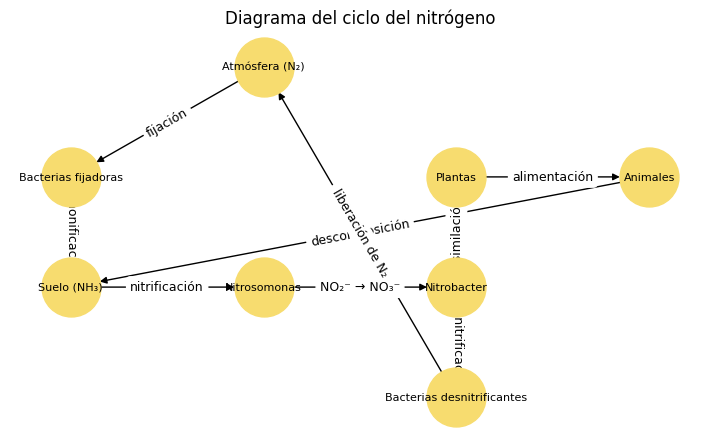

In [ ]:

# Diagrama simplificado del ciclo del nitrógeno
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()
nodos = ['Atmósfera (N₂)', 'Bacterias fijadoras', 'Suelo (NH₃)', 'Nitrosomonas', 'Nitrobacter', 'Plantas', 'Animales', 'Bacterias desnitrificantes']
G.add_nodes_from(nodos)
G.add_edge('Atmósfera (N₂)', 'Bacterias fijadoras', label='fijación')
G.add_edge('Bacterias fijadoras', 'Suelo (NH₃)', label='amonificación')
G.add_edge('Suelo (NH₃)', 'Nitrosomonas', label='nitrificación')
G.add_edge('Nitrosomonas', 'Nitrobacter', label='NO₂⁻ → NO₃⁻')
G.add_edge('Nitrobacter', 'Plantas', label='asimilación')
G.add_edge('Plantas', 'Animales', label='alimentación')
G.add_edge('Animales', 'Suelo (NH₃)', label='descomposición')
G.add_edge('Nitrobacter', 'Bacterias desnitrificantes', label='desnitrificación')
G.add_edge('Bacterias desnitrificantes', 'Atmósfera (N₂)', label='liberación de N₂')
pos = {
    'Atmósfera (N₂)':(0,2),
    'Bacterias fijadoras':(-1,1),
    'Suelo (NH₃)':(-1,0),
    'Nitrosomonas':(0,0),
    'Nitrobacter':(1,0),
    'Plantas':(1,1),
    'Animales':(2,1),
    'Bacterias desnitrificantes':(1,-1)
}
plt.figure(figsize=(7,4))
nx.draw(G, pos, with_labels=True, node_size=1800, node_color='#f7dc6f', font_size=8)
edge_labels = nx.get_edge_attributes(G,'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)
plt.title('Diagrama del ciclo del nitrógeno')
plt.axis('off')
plt.show()


Fijación biológica: N₂ → NH₃ por bacterias / rizobios.

Fijación abiótica: relámpagos + proceso Haber-Bosch.

Nitrificación y desnitrificación: NH₃ ↔ NO₃⁻ ↔ N₂.

Relevancia térmica: combustión a alta T → NOₓ → lluvia ácida, smog fotoquímico.

## Ciclo del azufre

El azufre es un elemento esencial presente en casi todas las proteínas y es necesario para las funciones metabólicas de plantas y animales. En los ecosistemas, el azufre circula desde el suelo o el agua a las plantas, luego a los animales y vuelve al suelo o al agua. Los compuestos sulfúricos se transportan al mar por los ríos; allí, procesos bacterianos y fisicoquímicos los convierten en gases como **H₂S** y **SO₂**, que ascienden a la atmósfera y regresan a tierra mediante la lluvia.

Las bacterias juegan un papel crucial en la descomposición de compuestos de azufre, generando sulfato (SO₄²⁻) bajo condiciones aeróbicas o sulfuro de hidrógeno (H₂S) y sulfuro de dimetilo bajo condiciones anaeróbicas. La oxidación atmosférica de estos gases produce **ácido sulfúrico**, que cae como lluvia ácida. El carbón mineral y el petróleo contienen azufre; su combustión libera dióxido de azufre a la atmósfera.

![Representación abstracta del ciclo del azufre](attachment:d3d2cd78-7024-47ab-84ab-1ccb3ffe1810.png)

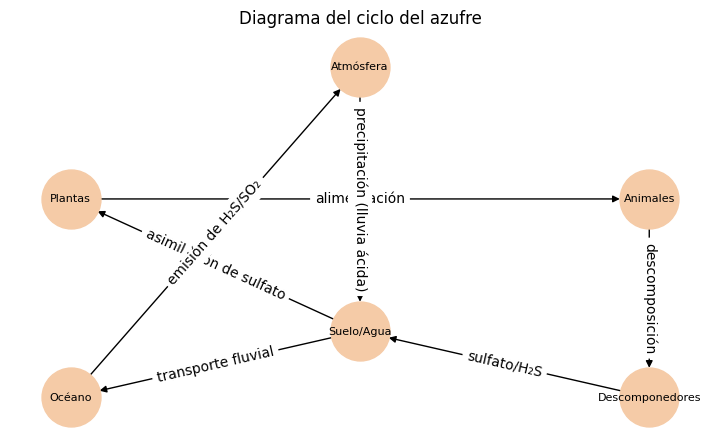

In [ ]:

# Diagrama simplificado del ciclo del azufre
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()
nodos = ['Suelo/Agua', 'Plantas', 'Animales', 'Descomponedores', 'Océano', 'Atmósfera']
G.add_nodes_from(nodos)
G.add_edge('Suelo/Agua', 'Plantas', label='asimilación de sulfato')
G.add_edge('Plantas', 'Animales', label='alimentación')
G.add_edge('Animales', 'Descomponedores', label='descomposición')
G.add_edge('Descomponedores', 'Suelo/Agua', label='sulfato/H₂S')
G.add_edge('Suelo/Agua', 'Océano', label='transporte fluvial')
G.add_edge('Océano', 'Atmósfera', label='emisión de H₂S/SO₂')
G.add_edge('Atmósfera', 'Suelo/Agua', label='precipitación (lluvia ácida)')
pos = {
    'Suelo/Agua':(0,0),
    'Plantas':(-1,1),
    'Animales':(1,1),
    'Descomponedores':(1,-0.5),
    'Océano':(-1,-0.5),
    'Atmósfera':(0,2)
}
plt.figure(figsize=(7,4))
nx.draw(G, pos, with_labels=True, node_size=1800, node_color='#f5cba7', font_size=8)
edge_labels = nx.get_edge_attributes(G,'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)
plt.title('Diagrama del ciclo del azufre')
plt.axis('off')
plt.show()


## Ciclo del fósforo

Aunque el fósforo representa una fracción pequeña de la biomasa, es esencial para la vida porque forma parte del ADN, del ATP y de los huesos y dientes. La mayor reserva de fósforo se encuentra en la **corteza terrestre** y en los depósitos de rocas marinas. El fósforo se libera de las rocas y pasa al suelo, donde las plantas lo absorben; los animales lo obtienen al alimentarse de plantas y de otros animales.

Los descomponedores liberan el fósforo como ortofosfatos, que pueden ser reutilizados por las plantas. A diferencia del carbono, nitrógeno y azufre, el fósforo **no tiene una fase gaseosa**; una vez que llega al océano, solo retorna a tierra firme mediante la acción de aves marinas que excretan fosfatos o por levantamiento geológico de los sedimentos. La explotación de rocas fosfáticas por los seres humanos también moviliza grandes cantidades de fósforo.

/tmp/ipython-input-1160255218.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


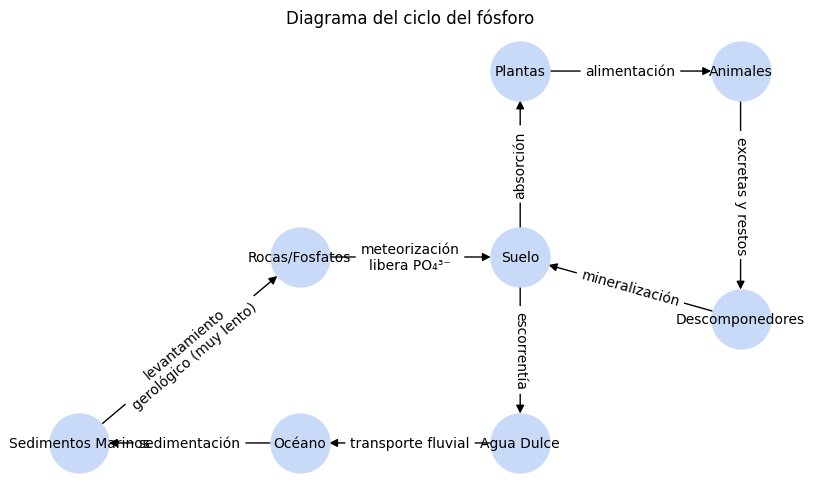

In [ ]:
# Diagrama simplificado del ciclo del fósforo
import matplotlib.pyplot as plt
import networkx as nx

# 1. Nodos principales del ciclo
nodos = [
    'Rocas/Fosfatos',   # depósitos minerales y fosforita
    'Suelo',            # fosfato inorgánico disponible
    'Plantas',          # asimilación de PO₄³⁻
    'Animales',         # ingestión de P orgánico
    'Descomponedores',  # mineralización de restos
    'Agua Dulce',       # ríos/lagos
    'Océano',           # aguas superficiales marinas
    'Sedimentos Marinos' # depósito de fosfatos
]

# 2. Aristas con los procesos clave
G = nx.DiGraph()
G.add_nodes_from(nodos)
G.add_edge('Rocas/Fosfatos', 'Suelo',          label='meteorización\nlibera PO₄³⁻')
G.add_edge('Suelo',          'Plantas',        label='absorción')
G.add_edge('Plantas',        'Animales',       label='alimentación')
G.add_edge('Animales',       'Descomponedores',label='excretas y restos')
G.add_edge('Descomponedores','Suelo',          label='mineralización')
G.add_edge('Suelo',          'Agua Dulce',     label='escorrentía')
G.add_edge('Agua Dulce',     'Océano',         label='transporte fluvial')
G.add_edge('Océano',         'Sedimentos Marinos', label='sedimentación')
G.add_edge('Sedimentos Marinos','Rocas/Fosfatos',  label='levantamiento\ngerológico (muy lento)')

# 3. Posiciones manuales para un layout legible
pos = {
    'Rocas/Fosfatos':     (-2,  0),
    'Suelo':              ( 0,  0),
    'Plantas':            ( 0,  1.2),
    'Animales':           ( 2,  1.2),
    'Descomponedores':    ( 2, -0.4),
    'Agua Dulce':         ( 0, -1.2),
    'Océano':             (-2,-1.2),
    'Sedimentos Marinos': (-4,-1.2)
}

# 4. Graficar
plt.figure(figsize=(8,4.5))
nx.draw(G, pos,
        with_labels=True,
        node_size=1800,
        node_color='#c9daf8',
        font_size=10,
        arrows=True,
        arrowstyle='-|>',
        arrowsize=12)

edge_labels = nx.get_edge_attributes(G,'label')
nx.draw_networkx_edge_labels(G, pos,
                             edge_labels=edge_labels,
                             font_size=10,
                             label_pos=0.5)

plt.title('Diagrama del ciclo del fósforo')
plt.axis('off')
plt.tight_layout()
plt.show()

## Geología de los combustibles fósiles

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 36 not upgraded.


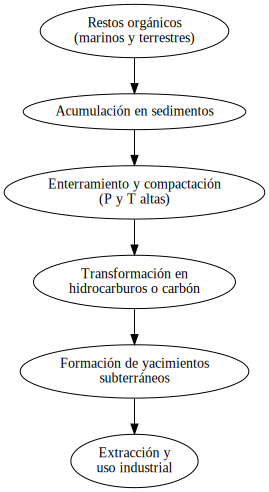

In [ ]:
# ==============================================
# Instalar Graphviz (si no está instalado)
# ==============================================
!apt-get update -qq
!apt-get install graphviz -y
!pip install graphviz

# ==============================================
# Generar y mostrar el diagrama
# ==============================================
from graphviz import Digraph

dot = Digraph(comment='Origen de los combustibles fósiles', format='png')

dot.node('A', 'Restos orgánicos\n(marinos y terrestres)')
dot.node('B', 'Acumulación en sedimentos')
dot.node('C', 'Enterramiento y compactación\n(P y T altas)')
dot.node('D', 'Transformación en\nhidrocarburos o carbón')
dot.node('E', 'Formación de yacimientos\nsubterráneos')
dot.node('F', 'Extracción y\nuso industrial')

dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D')
dot.edge('D', 'E')
dot.edge('E', 'F')

# Renderiza el diagrama a un archivo y lo muestra
dot.render('origen_combustibles_fosiles', view=True)

# Si deseas verlo embebido directamente en el notebook, simplemente:
dot

## Formación geológica del carbón

El carbón se formó a partir de restos de vegetación que crecieron hace cientos de millones de años. Durante el **período Carbonífero** (hace 350–280 Ma) y el **Pérmico** (280–225 Ma) grandes bosques de helechos y árboles depositaron capas de materia vegetal en zonas pantanosas. Estos restos quedaron enterrados bajo sedimentos y fueron transformados por hongos y bacterias en condiciones **anaeróbicas**. El proceso de **carbonificación** implica la compactación, eliminación de humedad y aumento del contenido de carbono, bajo temperaturas moderadas (~250 °C) y altas presiones. A medida que aumentan la profundidad y el tiempo de enterramiento, la materia vegetal se convierte progresivamente en turba, lignito, hulla y antracita, con incrementos en el poder calorífico.

La calidad del carbón se evalúa por su porcentaje de **carbono fijo**, materia volátil, humedad y azufre; cuanto mayor es el contenido de carbono y la antigüedad, mayor es su rango y capacidad calorífica.

El carbón se clasifica en diferentes tipos según su contenido de carbono: turba, lignito, sub-bituminoso, bituminoso y antracita.

a. Turba:

![Peat](https://upload.wikimedia.org/wikipedia/commons/7/7d/Peat_%2849302157252%29.jpg)

b. Lignito

![Lignite](https://upload.wikimedia.org/wikipedia/commons/8/85/Pliocene_Lignite_Coal_Serbia.jpg)

c. Sub-bituminoso

![Bituminous](https://upload.wikimedia.org/wikipedia/commons/2/20/Coal_bituminous.jpg)

d. Bituminoso:

![Bituminous](https://upload.wikimedia.org/wikipedia/commons/2/2e/Handvoll_Gold.jpg)

e. Antracita:

![Anthracite](https://upload.wikimedia.org/wikipedia/commons/5/59/Anthracite_Coal_01_10x_%2838960276634%29.jpg)

![Peat](https://upload.wikimedia.org/wikipedia/commons/a/a1/Formation_periods_of_the_most_important_coal_deposits_worldwide.svg)

![Representación abstracta de la formación de combustibles fósiles](attachment:b2c5755c-f6af-496e-ada9-07f3c3d10fc4.png)

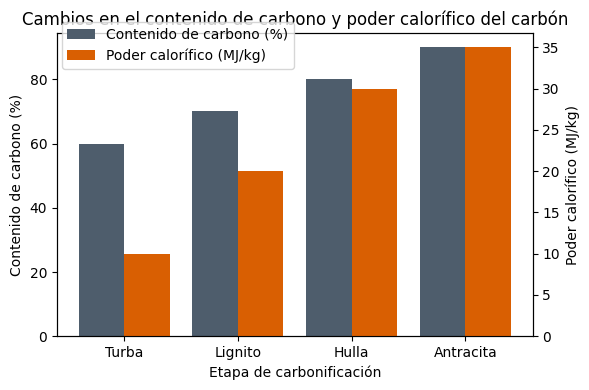

In [ ]:

# Evolución del contenido de carbono durante la carbonificación
import numpy as np
import matplotlib.pyplot as plt

etapas = ['Turba','Lignito','Hulla','Antracita']
contenido_carbono = [60, 70, 80, 90]  # porcentaje aproximado de carbono
poder_calorifico = [10, 20, 30, 35]    # MJ/kg aproximados
x = np.arange(len(etapas))
fig, ax1 = plt.subplots(figsize=(6,4))
ax1.bar(x-0.2, contenido_carbono, width=0.4, color='#4e5d6c', label='Contenido de carbono (%)')
ax2 = ax1.twinx()
ax2.bar(x+0.2, poder_calorifico, width=0.4, color='#d95f02', label='Poder calorífico (MJ/kg)')
ax1.set_xlabel('Etapa de carbonificación')
ax1.set_ylabel('Contenido de carbono (%)')
ax2.set_ylabel('Poder calorífico (MJ/kg)')
ax1.set_xticks(x)
ax1.set_xticklabels(etapas)
fig.legend(loc='upper left', bbox_to_anchor=(0.1,0.95))
plt.title('Cambios en el contenido de carbono y poder calorífico del carbón')
plt.tight_layout()
plt.show()


## Formación del petróleo y del gas natural

El petróleo y el gas natural se formaron a partir de restos de **organismos marinos** (zooplancton y fitoplancton) que se depositaron en fondos oceánicos ricos en sedimentos. El material orgánico fue enterrado rápidamente por aluviones y sedimentos fluviales, evitando su descomposición completa. Con el tiempo, la acumulación de sedimentos generó altas presiones y temperaturas que transformaron la materia orgánica en mezclas de hidrocarburos líquidos y gaseosos. Estas mezclas se alojaron en espacios porosos de rocas sedimentarias, formando **trampas** de petróleo y gas selladas por capas impermeables.

Formación del petróleo y gas natural (resumen):
- Materia orgánica marina se acumula en cuencas sedimentarias.
- El enterramiento y la falta de oxígeno impiden la descomposición y favorecen la transformación en hidrocarburos.
- La presión y el calor convierten la materia en petróleo y gas natural.
- Los hidrocarburos migran y se acumulan en rocas porosas bajo trampas geológicas.

Petroleo:

![Peat](https://upload.wikimedia.org/wikipedia/commons/a/ad/Crude_Oil_20180405_153958.jpg)

Gas Natural:

![Peat](https://upload.wikimedia.org/wikipedia/commons/8/8a/Darvasa_gas_crater_panorama.jpg)


| Etapa           | Proceso                                                                           | Tiempo escalado |
| --------------- | --------------------------------------------------------------------------------- | --------------- |
| **Generación**  | Transformación de materia orgánica a querógeno y luego a petróleo/gas (pirólisis) | 10⁶–10⁷ años    |
| **Migración**   | Desplazamiento del fluido hacia rocas reservorio                                  | continua        |
| **Acumulación** | Atrapamiento en estructuras anticlinales, fallas, domos salinos                   | continua        |


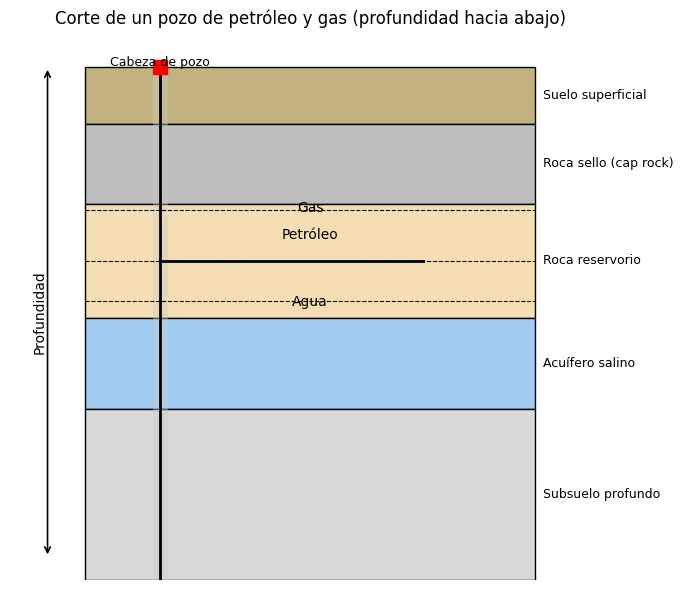

In [ ]:
# Corte vertical de un pozo de petróleo y gas (profundidad hacia abajo)
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(7, 6))

# ------------------------------------------------------------------
# 1. Capas geológicas: (nombre, profundidad tope [km], espesor [km], color)
layers = [
    ("Suelo superficial",      0.00, 0.5, "#c2b280"),
    ("Roca sello (cap rock)",  0.50, 0.7, "#bdbdbd"),
    ("Roca reservorio",        1.20, 1.0, "#f5deb3"),
    ("Acuífero salino",        2.20, 0.8, "#a1caf1"),
    ("Subsuelo profundo",      3.00, 1.5, "#d9d9d9")
]

for name, top, thick, color in layers:
    rect = patches.Rectangle((0, top), 6, thick,
                             facecolor=color, edgecolor='k', lw=1)
    ax.add_patch(rect)
    ax.text(6.1, top + thick/2, name, va='center', fontsize=9)

# ------------------------------------------------------------------
# 2. Distribución de fluidos en la roca reservorio
top_res, thick_res = 1.20, 1.0
y_gas   = top_res + 0.05               # interfaz gas
y_oil   = top_res + 0.50               # interfaz petróleo-agua
y_water = top_res + 0.85               # base agua

ax.hlines([y_gas, y_oil, y_water], 0, 6, colors='k', ls='--', lw=0.8)
ax.text(3, y_gas   + 0.05, "Gas",       ha='center', va='bottom', fontsize=10)
ax.text(3, (y_gas + y_oil)/2, "Petróleo",ha='center', va='center', fontsize=10)
ax.text(3, y_water - 0.05, "Agua",      ha='center', va='top', fontsize=10)

# ------------------------------------------------------------------
# 3. Pozo vertical y rama horizontal
ax.add_line(Line2D([1, 1], [0, 4.5], color='black', lw=2))             # pozo vertical
ax.add_patch(patches.Rectangle((0.9, 0), 0.2, 4.5, facecolor='#cccccc', alpha=0.4))  # casing
ax.add_line(Line2D([1, 4.5], [y_oil, y_oil], color='black', lw=2))     # rama horizontal

# Cabeza de pozo
ax.plot(1, 0, marker='s', ms=10, color='red')
ax.text(1, -0.1, "Cabeza de pozo", ha='center', va='top', fontsize=9)

# ------------------------------------------------------------------
# 4. Flecha de profundidad (eje invertido)
ax.annotate("", xy=(-0.5, 4.3), xytext=(-0.5, 0),
            arrowprops=dict(arrowstyle="<->", lw=1.2))
ax.text(-0.6, 2.15, "Profundidad", rotation=90, ha='center', va='center')

# ------------------------------------------------------------------
# Ajustes finales
ax.set_xlim(-1, 7)
ax.set_ylim(4.5, -0.3)          # invertido: superficie arriba, profundidad abajo
ax.set_title("Corte de un pozo de petróleo y gas (profundidad hacia abajo)", fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()


![Peat](https://upload.wikimedia.org/wikipedia/commons/c/ce/Uinta_Basin_geologic_cross_section.png)

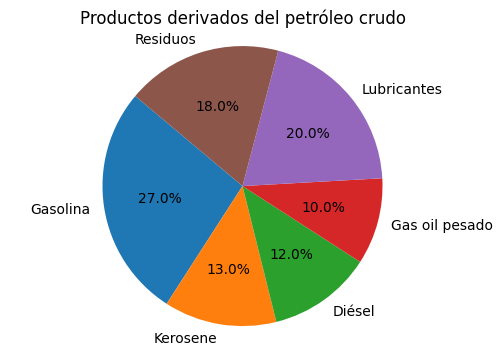

In [ ]:

# Distribución aproximada de los productos derivados del petróleo crudo
import matplotlib.pyplot as plt

labels = ['Gasolina','Kerosene','Diésel','Gas oil pesado','Lubricantes','Residuos']
valores = [27,13,12,10,20,18]  # Porcentaje en volumen basado en una mezcla típica
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']
plt.figure(figsize=(6,4))
plt.pie(valores, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.axis('equal')
plt.title('Productos derivados del petróleo crudo')
plt.show()


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.


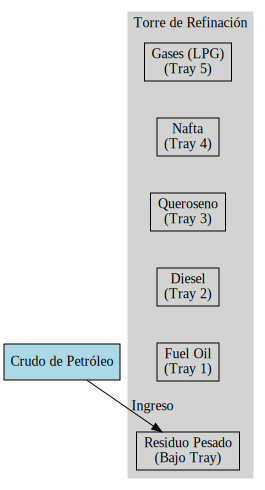

In [ ]:
# Instalar Graphviz (si es necesario) en Colab/Jupyter:
!apt-get update -qq
!apt-get install graphviz -y
!pip install graphviz

from graphviz import Digraph

dot = Digraph(comment='Torre de Refinación del Petróleo', format='png')
dot.attr(rankdir='TB', size='8,10')

# Nodo de alimentación: Crudo de Petróleo
dot.node('A', 'Crudo de Petróleo', shape='box', style='filled', fillcolor='lightblue')

# Crear un cluster para representar la torre de refinación
with dot.subgraph(name='cluster_tower') as c:
    c.attr(label='Torre de Refinación', style='filled', color='lightgrey')
    # Dentro de la torre, se extraen fracciones de menor a mayor volatilidad (de abajo hacia arriba)
    c.node('B', 'Residuo Pesado\n(Bajo Tray)', shape='box')
    c.node('C', 'Fuel Oil\n(Tray 1)', shape='box')
    c.node('D', 'Diesel\n(Tray 2)', shape='box')
    c.node('E', 'Queroseno\n(Tray 3)', shape='box')
    c.node('F', 'Nafta\n(Tray 4)', shape='box')
    c.node('G', 'Gases (LPG)\n(Tray 5)', shape='box')

    # Usar aristas invisibles para ordenar verticalmente las fracciones
    c.edge('G', 'F', style='invis')
    c.edge('F', 'E', style='invis')
    c.edge('E', 'D', style='invis')
    c.edge('D', 'C', style='invis')
    c.edge('C', 'B', style='invis')

# Conectar el crudo a la entrada de la torre (se alimenta en la parte baja)
dot.edge('A', 'B', label='Ingreso')

# Mostrar el diagrama (en entornos compatibles se visualizará la imagen)
dot.render('torre_refinacion_petróleo', view=True)
dot

## Conclusión

Los ciclos biogeoquímicos integran la química de la vida con los procesos geológicos. El ciclo del agua distribuye la energía y los nutrientes y controla la erosión; el ciclo del carbono regula el clima y da origen a combustibles fósiles; el ciclo del nitrógeno suministra nutrientes esenciales para la síntesis de proteínas y ácidos nucleicos; el ciclo del azufre influye en la composición atmosférica y en la acidez de la lluvia; el ciclo del fósforo sostiene la transferencia de energía en las células.

La formación del carbón, el petróleo y el gas natural es un ejemplo de cómo la materia orgánica, capturada inicialmente por la fotosíntesis, puede transformarse y almacenarse en la litosfera durante millones de años. Comprender estos procesos ayuda a los ingenieros mecánicos a valorar los recursos energéticos, su disponibilidad, y los impactos ambientales asociados a su uso.
